# Simulação de Difusão por Random Walk
## Atividade Prática — HPC Heisenberg

---

### O Fenômeno

Em 1827, o botânico Robert Brown observou ao microscópio que grãos de pólen em água se moviam de forma errática e imprevisível. Em 1905, Albert Einstein explicou matematicamente esse fenômeno: as partículas estão sendo bombardeadas continuamente por moléculas de água em movimento térmico.

Esse processo — o **movimento Browniano** — é um dos padrões mais universais da natureza:

| Escala | Fenômeno |
|---|---|
| Molecular | Difusão de proteínas em membranas |
| Celular | Migração de células em tecidos |
| Ecológico | Dispersão de organismos |
| Social | Difusão de rumores e informações |
| Financeiro | Modelos de precificação de ativos |

---

### A Lei de Einstein

A grandeza central é o **Deslocamento Quadrático Médio** (MSD):

$$\text{MSD}(t) = \langle |\mathbf{r}(t) - \mathbf{r}(0)|^2 \rangle = 2dDt$$

onde $d = 2$ (dimensões do espaço), $D$ é o coeficiente de difusão e $t$ é o tempo. **A relação é linear!**

---

### Este Notebook

Vamos:
1. Implementar e visualizar a *random walk* passo a passo
2. Verificar empiricamente a lei de Einstein
3. Comparar a performance de CPU vs. GPU
4. Explorar boas práticas de HPC


---
## Parte 0 — Configuração do Ambiente

Primeiro, verificamos quais recursos estão disponíveis neste nó.

In [ ]:
import os
import platform
import subprocess

import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats

# Configuração de estilo dos gráficos
plt.rcParams.update({
    'figure.dpi': 120,
    'font.size': 11,
    'axes.grid': True,
    'grid.alpha': 0.3,
})

# Cria diretório para armazenamento dos gráficos gerados
Path('results').mkdir(exist_ok=True)

print(f"Python: {platform.python_version()}")
print(f"NumPy:  {np.__version__}")
print(f"Nó:     {platform.node()}")
print(f"Job ID: {os.environ.get('SLURM_JOB_ID', 'local (não é um job SLURM)')}")

Python: 3.11.15
NumPy:  2.4.3
Nó:     work1
Job ID: 4912


In [2]:
# Verifica se há GPU disponível
try:
    import torch
    if torch.cuda.is_available():
        gpu_nome = torch.cuda.get_device_name(0)
        gpu_mem = torch.cuda.get_device_properties(0).total_memory / 1024**3
        print(f"✅ GPU disponível: {gpu_nome} ({gpu_mem:.1f} GiB)")
        DEVICE = "cuda"
    else:
        print("⚠️  PyTorch instalado, mas sem GPU (CUDA não disponível).")
        print("   Execute este notebook via job_gpu.sh para usar a GPU.")
        DEVICE = "cpu"
except ImportError:
    print("❌ PyTorch não instalado. Apenas CPU disponível.")
    DEVICE = "cpu"

print(f"\nDispositivo ativo: {DEVICE.upper()}")

✅ GPU disponível: Tesla T4 (14.6 GiB)

Dispositivo ativo: CUDA


In [3]:
# Mostra status da GPU (equivalente a rodar nvidia-smi no terminal)
try:
    result = subprocess.run(['nvidia-smi'], capture_output=True, text=True)
    print(result.stdout)
except FileNotFoundError:
    print("nvidia-smi não disponível neste nó.")

Wed Apr  1 21:29:06 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 590.48.01              Driver Version: 590.48.01      CUDA Version: 13.1     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       On  |   00000000:E2:00.0 Off |                    0 |
| N/A   32C    P8             10W /   70W |       8MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

---
## Parte 1 — Uma Partícula, Passo a Passo

Antes de simular milhares de partículas, entendemos o caso mais simples: **uma única partícula** se movendo em 2D.

In [4]:
# Parâmetros
N_STEPS = 1000   # número de passos
SEED = 42        # semente aleatória (para reprodutibilidade!)

rng = np.random.default_rng(SEED)

# Em cada passo: +1 ou -1 em x e y, com igual probabilidade
passos = rng.choice([-1, +1], size=(N_STEPS, 2))

# Posição = acumulação dos passos
# np.cumsum(eixo=0): soma cumulativa ao longo do tempo
posicoes = np.vstack([[0, 0], np.cumsum(passos, axis=0)])

print(f"Shape dos passos   : {passos.shape}    ← (n_steps, 2 dimensões)")
print(f"Shape das posições : {posicoes.shape}  ← (n_steps+1, 2 dimensões)")
print(f"\nPrimeiros 5 passos:")
print(passos[:5])
print(f"\nPrimeiras 5 posições:")
print(posicoes[:5])

Shape dos passos   : (1000, 2)    ← (n_steps, 2 dimensões)
Shape das posições : (1001, 2)  ← (n_steps+1, 2 dimensões)

Primeiros 5 passos:
[[-1  1]
 [ 1 -1]
 [-1  1]
 [-1  1]
 [-1 -1]]

Primeiras 5 posições:
[[ 0  0]
 [-1  1]
 [ 0  0]
 [-1  1]
 [-2  2]]


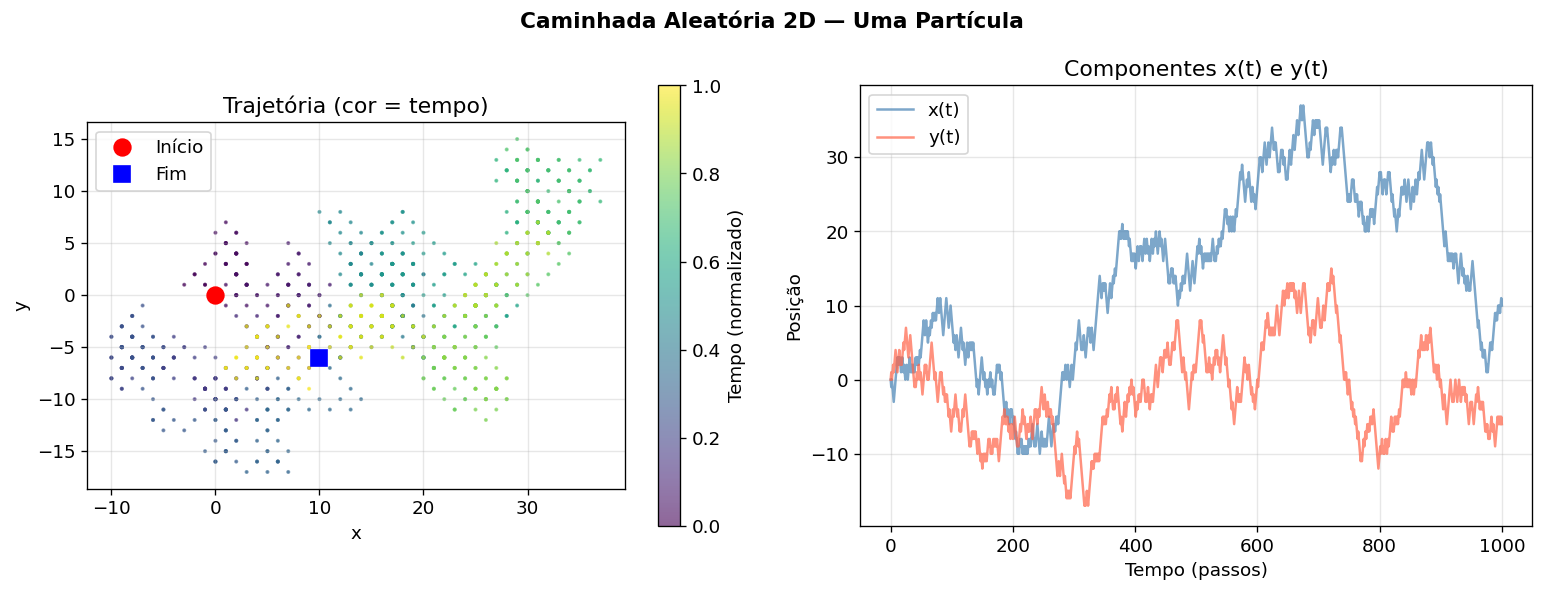

Distância final da origem: 11.7 unidades
Distância esperada (√N):   31.6 unidades


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Caminhada Aleatória 2D — Uma Partícula", fontsize=13, fontweight='bold')

# Trajetória no plano xy
ax = axes[0]
t_norm = np.linspace(0, 1, len(posicoes))
sc = ax.scatter(posicoes[:, 0], posicoes[:, 1],
                c=t_norm, cmap='viridis', s=2, alpha=0.6)
plt.colorbar(sc, ax=ax, label='Tempo (normalizado)')
ax.plot(*posicoes[0], 'ro', markersize=10, label='Início', zorder=5)
ax.plot(*posicoes[-1], 'bs', markersize=10, label='Fim', zorder=5)
ax.set_xlabel('x'); ax.set_ylabel('y')
ax.set_title('Trajetória (cor = tempo)')
ax.legend(); ax.set_aspect('equal')

# Posição x e y separadamente ao longo do tempo
ax = axes[1]
t = np.arange(len(posicoes))
ax.plot(t, posicoes[:, 0], alpha=0.7, label='x(t)', color='steelblue')
ax.plot(t, posicoes[:, 1], alpha=0.7, label='y(t)', color='tomato')
ax.set_xlabel('Tempo (passos)'); ax.set_ylabel('Posição')
ax.set_title('Componentes x(t) e y(t)')
ax.legend()

plt.tight_layout()
plt.show()

dist_final = np.sqrt(posicoes[-1,0]**2 + posicoes[-1,1]**2)
print(f"Distância final da origem: {dist_final:.1f} unidades")
print(f"Distância esperada (√N):   {np.sqrt(N_STEPS):.1f} unidades")

---
## Parte 2 — Muitas Partículas e a Lei de Einstein

Com uma única partícula, o resultado é aleatório. O poder da lei de Einstein surge quando **calculamos a média sobre muitas partículas independentes**.

In [6]:
import time

# Parâmetros
N_PARTICLES = 10_000   # ← tente aumentar para 100_000 e observe o tempo!
N_STEPS = 300
STEP_SIZE = 1.0

rng = np.random.default_rng(SEED)

print(f"Simulando {N_PARTICLES:,} partículas por {N_STEPS} passos em CPU...")
t0 = time.perf_counter()

# Passos: shape (N_STEPS, N_PARTICLES, 2)
passos = rng.choice([-STEP_SIZE, +STEP_SIZE],
                     size=(N_STEPS, N_PARTICLES, 2)).astype(np.float32)

# Posições: shape (N_STEPS+1, N_PARTICLES, 2)
positions = np.zeros((N_STEPS + 1, N_PARTICLES, 2), dtype=np.float32)
np.cumsum(passos, axis=0, out=positions[1:])

# MSD: média sobre partículas de (x² + y²)
msd_cpu = np.mean(positions[:, :, 0]**2 + positions[:, :, 1]**2, axis=1)

t_cpu = time.perf_counter() - t0
print(f"Concluído em {t_cpu:.3f} s")
print(f"Memória usada: {positions.nbytes / 1024**2:.1f} MiB")

Simulando 10,000 partículas por 300 passos em CPU...
Concluído em 0.097 s
Memória usada: 23.0 MiB


In [7]:
# Ajuste linear do MSD para estimar D
t = np.arange(len(msd_cpu), dtype=float)
slope, intercept, r_value, _, _ = stats.linregress(t, msd_cpu)

D_estimado = slope / 4.0           # MSD = 2*d*D*t → D = slope/(2*2)
D_teorico = STEP_SIZE**2 / 2.0     # derivado analiticamente
erro_pct = abs(D_estimado - D_teorico) / D_teorico * 100

print(f"Coeficiente de difusão estimado: D = {D_estimado:.5f}")
print(f"Valor teórico esperado:          D = {D_teorico:.5f}")
print(f"Erro relativo: {erro_pct:.3f}%")
print(f"R² do ajuste linear: {r_value**2:.6f}")

Coeficiente de difusão estimado: D = 0.51206
Valor teórico esperado:          D = 0.50000
Erro relativo: 2.413%
R² do ajuste linear: 0.999849


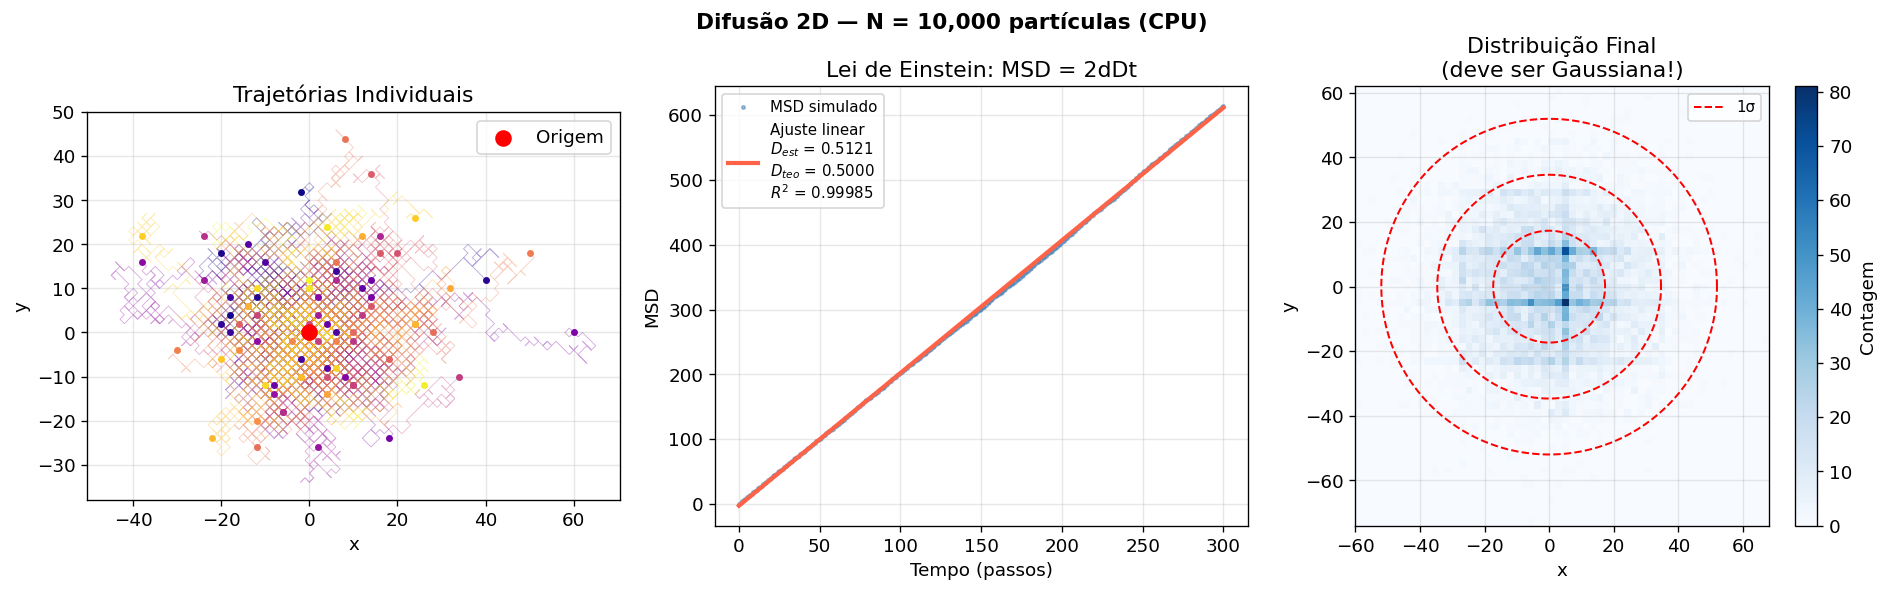

Figura salva em results/difusao_notebook.png


In [10]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle(f"Difusão 2D — N = {N_PARTICLES:,} partículas (CPU)",
             fontsize=13, fontweight='bold')

# Painel 1: Trajetórias
ax = axes[0]
n_plot = 80
cmap = plt.get_cmap('plasma')
for i in range(n_plot):
    cor = cmap(i / n_plot)
    ax.plot(positions[:, i, 0], positions[:, i, 1],
            alpha=0.35, linewidth=0.5, color=cor)
    ax.scatter(*positions[-1, i], s=10, color=cor, zorder=5)
ax.scatter(0, 0, s=80, color='red', zorder=10, label='Origem')
ax.set_title('Trajetórias Individuais'); ax.legend()
ax.set_xlabel('x'); ax.set_ylabel('y'); ax.set_aspect('equal')

# Painel 2: MSD vs Tempo
ax = axes[1]
ax.plot(t, msd_cpu, 'o', markersize=2, alpha=0.5,
        color='steelblue', label='MSD simulado')
ax.plot(t, slope*t + intercept, '-', color='tomato', linewidth=2.5,
        label=f'Ajuste linear\n$D_{{est}}$ = {D_estimado:.4f}\n'
              f'$D_{{teo}}$ = {D_teorico:.4f}\n$R^2$ = {r_value**2:.5f}')
ax.set_title('Lei de Einstein: MSD = 2dDt')
ax.set_xlabel('Tempo (passos)'); ax.set_ylabel('MSD')
ax.legend(fontsize=9)

# Painel 3: Distribuição das posições finais
ax = axes[2]
x_f = positions[-1, :, 0]; y_f = positions[-1, :, 1]
h = ax.hist2d(x_f, y_f, bins=60, cmap='Blues')
fig.colorbar(h[3], ax=ax, label='Contagem')
sigma_teo = np.sqrt(2 * D_teorico * N_STEPS)
theta = np.linspace(0, 2*np.pi, 200)
for k in [1, 2, 3]:
    ax.plot(k*sigma_teo*np.cos(theta), k*sigma_teo*np.sin(theta),
            '--r', linewidth=1.2, label=f'{k}σ' if k==1 else f'_{k}σ')
ax.set_title('Distribuição Final\n(deve ser Gaussiana!)')
ax.set_xlabel('x'); ax.set_ylabel('y'); ax.set_aspect('equal')
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig('results/difusao_notebook.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figura salva em results/difusao_notebook.png")

---
## Parte 3 — CPU vs. GPU: Quando Vale a Pena?

Agora vamos medir empiricamente a diferença de desempenho.

In [11]:
def simular_numpy(n, t, seed):
    """Simulação CPU usando NumPy."""
    rng = np.random.default_rng(seed)
    passos = rng.choice([-1.0, 1.0], size=(t, n, 2)).astype(np.float32)
    pos = np.zeros((t+1, n, 2), dtype=np.float32)
    np.cumsum(passos, axis=0, out=pos[1:])
    return np.mean(pos[:,:,0]**2 + pos[:,:,1]**2, axis=1)

def simular_torch(n, t, seed, device):
    """Simulação GPU/CPU usando PyTorch."""
    import torch
    torch.manual_seed(seed)
    dev = torch.device(device)
    passos = (torch.bernoulli(torch.full((t, n, 2), 0.5, device=dev))*2-1)
    pos = torch.zeros((t+1, n, 2), dtype=torch.float32, device=dev)
    torch.cumsum(passos, dim=0, out=pos[1:])
    msd = torch.mean(pos[:,:,0]**2 + pos[:,:,1]**2, dim=1)
    if device == 'cuda':
        torch.cuda.synchronize()
    return msd.cpu().numpy()

T_BENCH = 200
N_VALS = [1_000, 5_000, 10_000, 50_000, 100_000]
if DEVICE == 'cuda':
    N_VALS.append(500_000)

tempos_cpu = []
tempos_gpu = [] if DEVICE == 'cuda' else None

print(f"{'N':>10} | {'CPU (s)':>10} | {'GPU (s)':>10} | {'Speedup':>10}")
print("-" * 50)

for n in N_VALS:
    # CPU
    t0 = time.perf_counter()
    simular_numpy(n, T_BENCH, SEED)
    tc = time.perf_counter() - t0
    tempos_cpu.append(tc)
    
    # GPU
    if DEVICE == 'cuda':
        # warm-up
        simular_torch(100, 10, SEED, DEVICE)
        t0 = time.perf_counter()
        simular_torch(n, T_BENCH, SEED, DEVICE)
        tg = time.perf_counter() - t0
        tempos_gpu.append(tg)
        sp = tc / tg
        print(f"{n:>10,} | {tc:>10.4f} | {tg:>10.4f} | {sp:>9.1f}×")
    else:
        print(f"{n:>10,} | {tc:>10.4f} | {'N/D':>10} | {'N/D':>10}")

         N |    CPU (s) |    GPU (s) |    Speedup
--------------------------------------------------
     1,000 |     0.0049 |     0.0020 |       2.5×
     5,000 |     0.0260 |     0.0015 |      16.9×
    10,000 |     0.0479 |     0.0016 |      29.1×
    50,000 |     0.2820 |     0.0066 |      42.7×
   100,000 |     0.4801 |     0.0121 |      39.6×
   500,000 |     2.3900 |     0.0556 |      43.0×


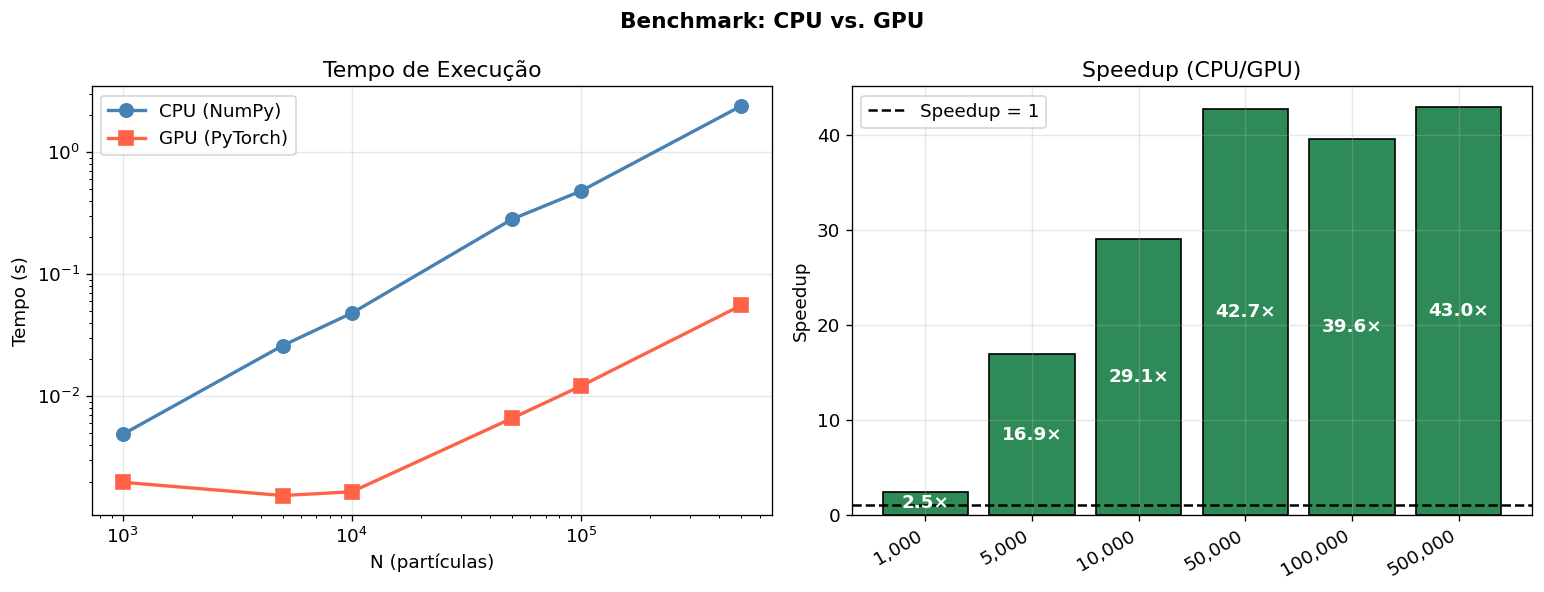

In [12]:
fig, axes = plt.subplots(1, 2 if tempos_gpu else 1, figsize=(13 if tempos_gpu else 7, 5))
if tempos_gpu is None:
    axes = [axes]

fig.suptitle('Benchmark: CPU vs. GPU', fontsize=13, fontweight='bold')

ax = axes[0]
ax.loglog(N_VALS, tempos_cpu, 'o-', color='steelblue', lw=2, ms=8, label='CPU (NumPy)')
if tempos_gpu:
    ax.loglog(N_VALS, tempos_gpu, 's-', color='tomato', lw=2, ms=8, label='GPU (PyTorch)')
ax.set_xlabel('N (partículas)'); ax.set_ylabel('Tempo (s)')
ax.set_title('Tempo de Execução'); ax.legend()

if tempos_gpu and len(axes) > 1:
    ax2 = axes[1]
    speedups = [tc/tg for tc, tg in zip(tempos_cpu, tempos_gpu)]
    cores = ['tomato' if s < 1 else 'seagreen' for s in speedups]
    ax2.bar(range(len(N_VALS)), speedups, color=cores, edgecolor='black')
    ax2.axhline(1, color='black', ls='--', lw=1.5, label='Speedup = 1')
    ax2.set_xticks(range(len(N_VALS)))
    ax2.set_xticklabels([f'{n:,}' for n in N_VALS], rotation=30, ha='right')
    for i, s in enumerate(speedups):
        ax2.text(i, s/2, f'{s:.1f}×', ha='center', va='center',
                 fontweight='bold', color='white' if s > 1.5 else 'black')
    ax2.set_title('Speedup (CPU/GPU)'); ax2.set_ylabel('Speedup')
    ax2.legend()

plt.tight_layout()
plt.savefig('results/benchmark_notebook.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Parte 4 — Boas Práticas: Reprodutibilidade

Rode as células abaixo e responda: os resultados mudam quando você altera a semente?

In [21]:
# ─── EXPERIMENTO DE REPRODUTIBILIDADE ───────────────────────────────────────
# Mude o valor de SEED_EXPERIMENTO e veja o que acontece com D_estimado.
# O coeficiente de difusão deve ser sempre próximo do valor teórico,
# independentemente da semente — isso é o que torna o método robusto.

SEED_EXPERIMENTO = 42   # ← MUDE ESTE VALOR e reexecute!

N = 20_000; T = 300
msd_rep = simular_numpy(N, T, SEED_EXPERIMENTO)
t_r = np.arange(len(msd_rep), dtype=float)
sl, _, rv, _, _ = stats.linregress(t_r, msd_rep)
D_rep = sl / 4.0

print(f"Seed utilizada   : {SEED_EXPERIMENTO}")
print(f"D estimado       : {D_rep:.5f}")
print(f"D teórico        : {STEP_SIZE**2/2:.5f}")
print(f"Erro relativo    : {abs(D_rep - STEP_SIZE**2/2)/(STEP_SIZE**2/2)*100:.3f}%")
print(f"R²               : {rv**2:.6f}")
print()
print("↑ Reexecute com seeds diferentes.")
print("  O D estimado deve ser sempre ~0.5 — isso é reprodutibilidade!")

Seed utilizada   : 42
D estimado       : 0.50209
D teórico        : 0.50000
Erro relativo    : 0.417%
R²               : 0.999948

↑ Reexecute com seeds diferentes.
  O D estimado deve ser sempre ~0.5 — isso é reprodutibilidade!


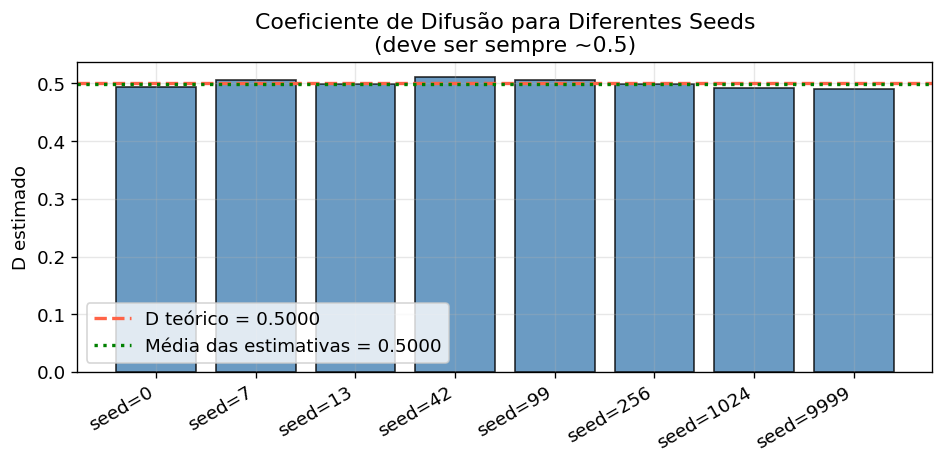

Desvio padrão entre as estimativas: 0.00685
Variação relativa: 1.37%


In [22]:
# Comparação entre múltiplas seeds (simulação de um experimento repetido)
seeds_teste = [0, 7, 13, 42, 99, 256, 1024, 9999]
Ds = []

for s in seeds_teste:
    msd_s = simular_numpy(10_000, 300, s)
    t_s = np.arange(len(msd_s), dtype=float)
    sl_s, _, _, _, _ = stats.linregress(t_s, msd_s)
    Ds.append(sl_s / 4.0)

Ds = np.array(Ds)
D_teo = STEP_SIZE**2 / 2.0

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(range(len(seeds_teste)), Ds, color='steelblue', edgecolor='black', alpha=0.8)
ax.axhline(D_teo, color='tomato', ls='--', lw=2,
           label=f'D teórico = {D_teo:.4f}')
ax.axhline(Ds.mean(), color='green', ls=':', lw=2,
           label=f'Média das estimativas = {Ds.mean():.4f}')
ax.set_xticks(range(len(seeds_teste)))
ax.set_xticklabels([f'seed={s}' for s in seeds_teste], rotation=30, ha='right')
ax.set_ylabel('D estimado')
ax.set_title('Coeficiente de Difusão para Diferentes Seeds\n(deve ser sempre ~0.5)')
ax.legend()
plt.tight_layout()
plt.savefig('results/reproducibilidade.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Desvio padrão entre as estimativas: {Ds.std():.5f}")
print(f"Variação relativa: {Ds.std()/D_teo*100:.2f}%")